# Soal 2

**a.** Baca dua citra dengan OpenCV.

**b.** Gabungkan kedua citra dengan `cv2.addWeighted` dan tampilkan hasilnya dengan Matplotlib.

**c.** Terapkan chroma keying (green screen matting) untuk mengganti latar belakang hijau.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## a. Baca dua citra dengan OpenCV

Citra 1 (minion_green_screen): (1080, 1920, 3)
Citra 2 (monas_bg): (667, 1000, 3)


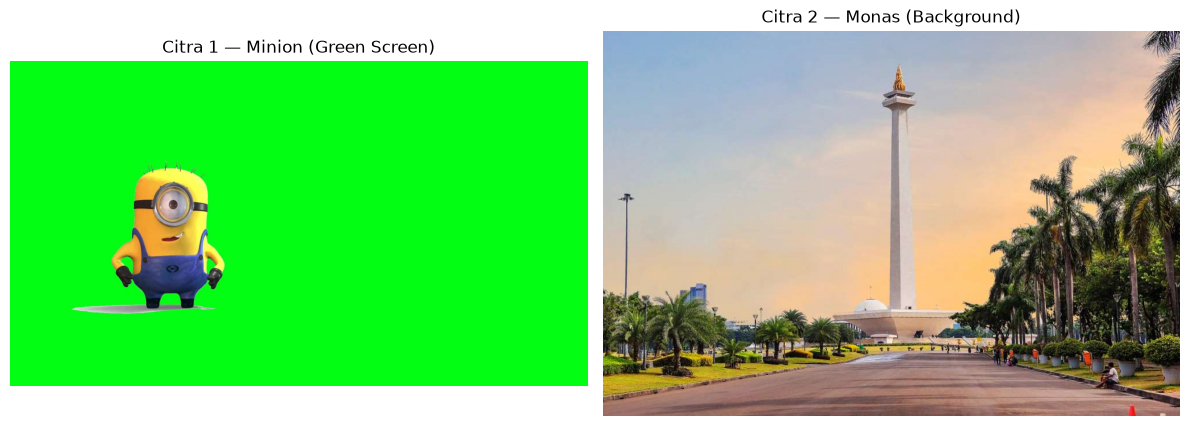

In [2]:
# Baca citra (OpenCV membaca dalam format BGR)
img1_bgr = cv2.imread('assets/minion_green_screen.jpg')
img2_bgr = cv2.imread('assets/monas_bg.jpeg')

# Konversi ke RGB untuk ditampilkan dengan Matplotlib
img1 = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)

print(f'Citra 1 (minion_green_screen): {img1.shape}')
print(f'Citra 2 (monas_bg): {img2.shape}')

# Tampilkan kedua citra
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img1)
axes[0].set_title('Citra 1 — Minion (Green Screen)')
axes[0].axis('off')
axes[1].imshow(img2)
axes[1].set_title('Citra 2 — Monas (Background)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## b. Gabungkan kedua citra dengan `cv2.addWeighted`

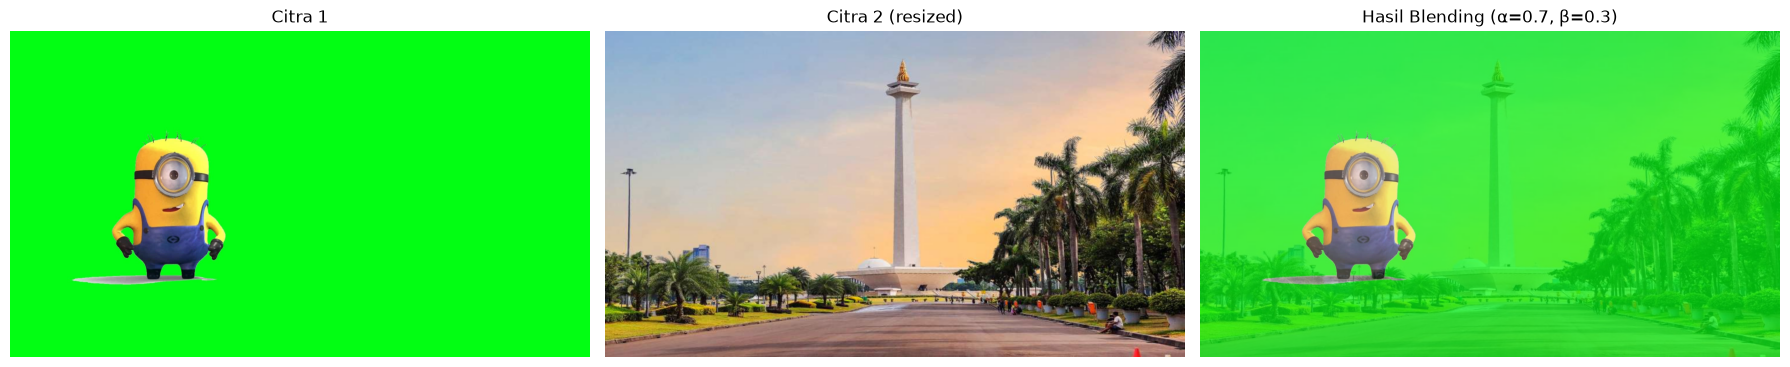

In [3]:
# Sesuaikan ukuran img2 agar sama dengan img1
img2_resized = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

# Gabungkan dengan cv2.addWeighted
# J = alpha * img1 + beta * img2 + gamma
alpha = 0.7  
beta = 0.3   
gamma = 0    # bias
blended = cv2.addWeighted(img1, alpha, img2_resized, beta, gamma)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img1)
axes[0].set_title('Citra 1')
axes[0].axis('off')
axes[1].imshow(img2_resized)
axes[1].set_title('Citra 2 (resized)')
axes[1].axis('off')
axes[2].imshow(blended)
axes[2].set_title(f'Hasil Blending (α={alpha}, β={beta})')
axes[2].axis('off')
plt.tight_layout()
plt.show()

## c. Chroma Keying (Green Screen Matting)

In [5]:
def chroma_key_green(img_rgb, background_rgb, a1=0.5): 
    n_rows, n_cols = img_rgb.shape[:2]

    # Resize background agar sesuai ukuran citra input
    bg_resized = cv2.resize(background_rgb, (n_cols, n_rows))

    # Ekstrak komponen RGB
    R_I = img_rgb[:, :, 0]
    G_I = img_rgb[:, :, 1]
    B_I = img_rgb[:, :, 2]

    # Hitung alpha matte
    G_B = 1.0
    alpha = (B_I - a1 * (G_I - G_B)) / (a1 * G_B)
    alpha = np.clip(alpha, 0, 1)
 
    G_F = np.minimum(G_I, B_I / a1)
 
    R_J = R_I + (1 - alpha) * bg_resized[:, :, 0]
    G_J = G_F + (1 - alpha) * bg_resized[:, :, 1]
    B_J = B_I + (1 - alpha) * bg_resized[:, :, 2]

    result = np.stack([R_J, G_J, B_J], axis=2)
    result = np.clip(result, 0, 1)

    return result, alpha

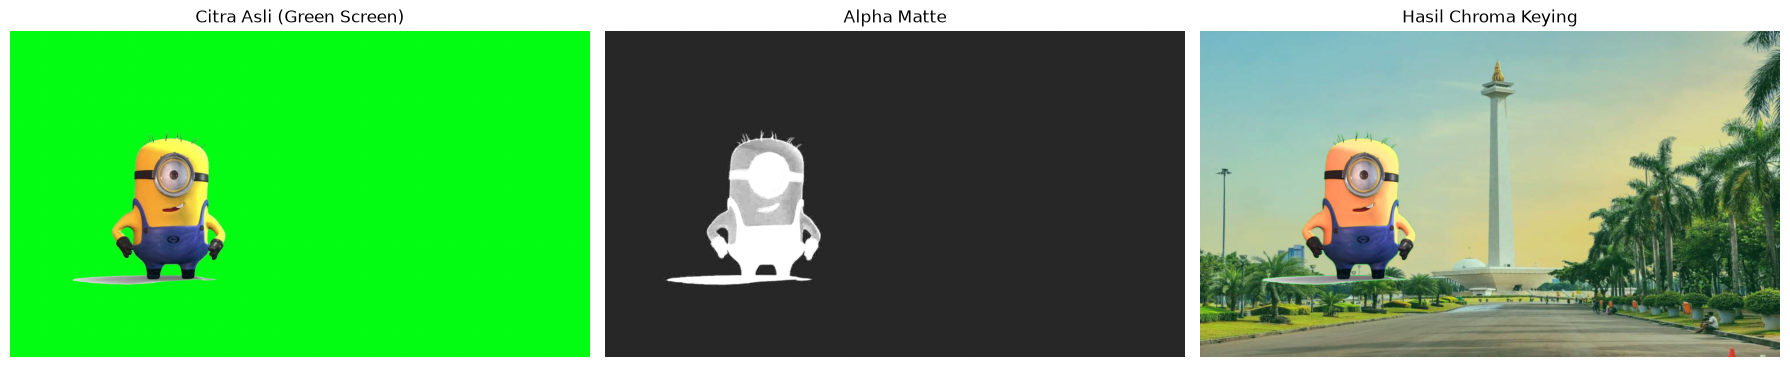

In [6]:
# Normalisasi citra ke float [0, 1]
img1_f = img1.astype(np.float64) / 255.0
img2_f = img2.astype(np.float64) / 255.0

result1, alpha1 = chroma_key_green(img1_f, img2_f)

# hasil
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(img1_f)
axes[0].set_title('Citra Asli (Green Screen)')
axes[0].axis('off')
axes[1].imshow(alpha1, cmap='gray')
axes[1].set_title('Alpha Matte')
axes[1].axis('off')
axes[2].imshow(result1)
axes[2].set_title('Hasil Chroma Keying')
axes[2].axis('off')
plt.tight_layout()
plt.show()